# Semi-implicit ABBA exact-Jacobian symplecticity study

This experiment evaluates `SemiImplicitABBA`, the tangent-propagating form of the second-order endpoint-time ABBA map closed by Hairer's symmetric projection. The physical trajectory is the same as for `SymmetricProjectedABBA`, but every converged main step also evaluates the exact ideal-root physical Jacobian derived in `docs/tex/ABBA_semiimplicit/ABBA_semiimplicit_English.tex`:

$$J_n=D\Psi_{h,t_n}(z_n)=\mathcal P-\mathcal Q\mathcal K^{-1}\mathcal L.$$

The implementation applies this formula with a linear solve, never by forming $\mathcal K^{-1}$. It propagates the complete tangent from the initial condition as

$$M_{n+1}=J_nM_n,\qquad M_0=I.$$

The recorded local and accumulated defects are

$$\varepsilon_{\mathrm{local},n}=\frac{\|J_n^T\Omega J_n-\Omega\|_F}{\|\Omega\|_F},\qquad \varepsilon_{\mathrm{flow},n}=\frac{\|M_n^T\Omega M_n-\Omega\|_F}{\|\Omega\|_F}.$$

No centered-difference Jacobian is evaluated in this study. The transported polygon area, $|\det(M_n)-1|$, Newton residuals, iteration counts, and projection multipliers provide complementary geometric and nonlinear-solver diagnostics.

In [1]:
import numpy as np

from workflows import (
    RandomPotentialConfig,
    SemiImplicitABBASymplecticityConfig,
    centered_circle,
    display_animation,
    pi_area_steps,
    run_semiimplicit_abba_symplecticity_study,
)

## Reproducible configuration

The random-potential seed and spectrum, interpolation order, boundary geometry, guiding-center radius, integration interval, three ABBA steps, observation interval, and Newton stopping parameters are explicit below. Fifth-order interpolation supplies the potential Hessians required by the exact stage Jacobians. There is deliberately no finite-difference scale.

In [2]:
potential_config = RandomPotentialConfig(
    amplitude=0.7,
    max_wave_number=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
potential = potential_config.build()

circle_radius = 0.5
circle_points = 16
rho = 0.3
circle = centered_circle(
    potential,
    radius=circle_radius,
    points=circle_points,
    rho=rho,
)

study_config = SemiImplicitABBASymplecticityConfig(
    steps=pi_area_steps(40, 80, 160),
    t_span=(0.0, 4 * np.pi),
    save_interval=np.pi / 8,
    chunk_size=16,
    progress=True,
    block_prefix="semiimplicit_abba_exact_symplecticity",
    newton_absolute_tolerance=1e-13,
    newton_relative_tolerance=1e-12,
    newton_max_iterations=12,
)

print(potential_config)
print(study_config)
print(
    f"Circle: {circle_points} points; t={study_config.t_span}; "
    f"{study_config.output_sample_count} saved states; "
    "step Jacobian=exact implicit-function tangent"
)

RandomPotentialConfig(amplitude=0.7, max_wave_number=25, nx=64, ny=64, seed=27, interpolation_order=5)
SemiImplicitABBASymplecticityConfig(steps=(AreaStep(label='$\\Delta t=\\pi/40$', value=0.07853981633974483), AreaStep(label='$\\Delta t=\\pi/80$', value=0.039269908169872414), AreaStep(label='$\\Delta t=\\pi/160$', value=0.019634954084936207)), t_span=(0.0, 12.566370614359172), save_interval=0.39269908169872414, chunk_size=16, progress=True, block_prefix='semiimplicit_abba_exact_symplecticity', finite_difference_relative_step=None, newton_absolute_tolerance=1e-13, newton_relative_tolerance=1e-12, newton_max_iterations=12)
Circle: 16 points; t=(0.0, 12.566370614359172); 33 saved states; step Jacobian=exact implicit-function tangent


## Semi-implicit ABBA integrations and persisted exact Jacobians

Newton starts from $\mu_0=0$ on every step, uses the infinity norm for its stopping test, and reevaluates the exact residual Jacobian after each correction. At convergence, the method evaluates the exact physical tangent $J_n$, propagates $M_n$, and gives the same local matrix to the observer. Scalar diagnostics and full local and accumulated matrices are persisted at the common observation times.

In [3]:
result = run_semiimplicit_abba_symplecticity_study(
    potential,
    circle,
    notebook_path=(
        "notebooks/experiments/symplecticity/"
        "gc_area_and_semiimplicit_abba_symplecticity.ipynb"
    ),
    config=study_config,
    metadata={
        **potential_config.metadata(),
        "circle_radius": circle_radius,
        "study_kind": "versioned_exact_jacobian_symplecticity_experiment",
    },
)
result.print_summary()

SemiImplicitABBA [>                             ]   3.1% (5/160, t=0.392699))

SemiImplicitABBA [==============================] 100.0% (160/160, t=12.5664)
SemiImplicitABBA [==============================] 100.0% (320/320, t=12.5664)
SemiImplicitABBA [==============================] 100.0% (640/640, t=12.5664)


                  step       SemiImplicitABBA steps     max |area error|     max local defect      max flow defect      max |det-1|
     $\Delta t=\pi/40$                          160       1.77718737e-02       1.40168122e-16       1.16169329e-15   5.66213743e-15
     $\Delta t=\pi/80$                          320       1.77812418e-02       1.60648051e-16       2.44884789e-15   1.04360964e-14
    $\Delta t=\pi/160$                          640       1.77835883e-02       1.48174565e-16       4.79011075e-15   1.70974346e-14

Nonlinear projection solve per main integration step:
  $\Delta t=\pi/40$: max/mean iterations=2/1.006, max residual=3.547e-12, max |mu|_inf=2.807e-05
  $\Delta t=\pi/80$: max/mean iterations=1/1.000, max residual=1.318e-14, max |mu|_inf=3.712e-06
  $\Delta t=\pi/160$: max/mean iterations=1/1.000, max residual=2.781e-15, max |mu|_inf=4.686e-07

The local matrices are exact implicit-function tangents evaluated at the converged ABBA stages. Reported defects therefore c

## Exact-tangent audit

Each solution must identify its tangent as the implicit-function Jacobian and retain the final accumulated matrix. These checks ensure that the experiment did not silently fall back to numerical differentiation.

In [4]:
for step in study_config.steps:
    solution = result.solutions[step.label]
    assert solution.diagnostics["state_jacobian_kind"] == "exact_implicit_function"
    final_jacobian = np.asarray(solution.diagnostics["final_state_jacobian"])
    assert final_jacobian.shape == (2 * circle_points, 2 * circle_points)
    assert np.all(np.isfinite(final_jacobian))
    print(
        f"{step.label}: final tangent shape={final_jacobian.shape}, "
        f"condition number={np.linalg.cond(final_jacobian):.8e}"
    )

$\Delta t=\pi/40$: final tangent shape=(32, 32), condition number=1.62899675e+01
$\Delta t=\pi/80$: final tangent shape=(32, 32), condition number=1.63053121e+01
$\Delta t=\pi/160$: final tangent shape=(32, 32), condition number=1.63091375e+01


## Time-dependent diagnostics

The local matrix defect tests each projected ABBA tangent independently. The accumulated defect and determinant error test the complete discrete flow from the initial boundary, while the area panel shows the transported polygon geometry.

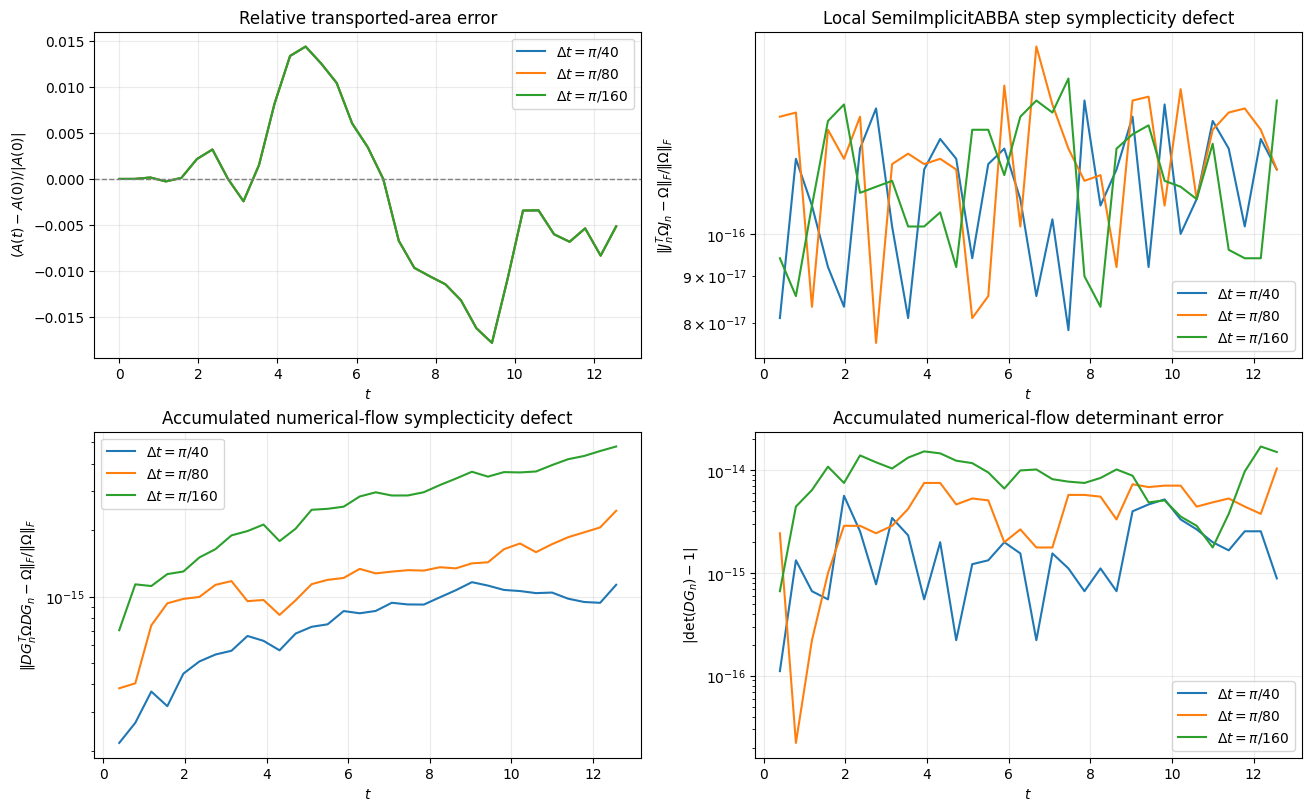

In [5]:
diagnostic_figure, diagnostic_axes = result.plot_diagnostics()

## Exact-Jacobian symplecticity floor

For an exact root, the physical ABBA tangent is structurally symplectic. Here its defect is evaluated directly from the implemented Jacobian, so there is no finite-difference truncation or cancellation error. The remaining floor reflects floating-point arithmetic, potential-Hessian evaluation, the finite Newton stopping tolerance, and accumulation over many steps; it is not a temporal convergence error.

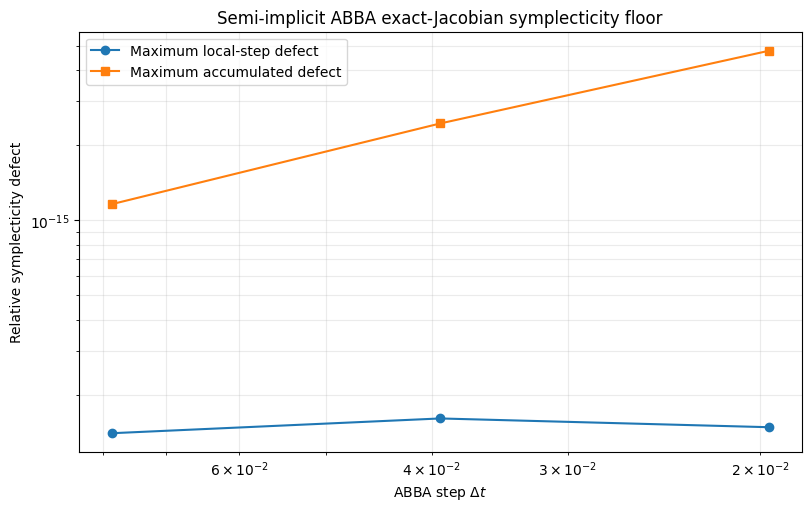

In [6]:
defect_floor_figure, defect_floor_axis = result.plot_defect_floor()

## Nonlinear projection diagnostics

The iteration and residual histories verify that the projection solve remains below its configured stopping threshold. The maximum multiplier is expected to decrease approximately as $O(h^3)$; this is a consistency property of the symmetric projection, not the global trajectory order.

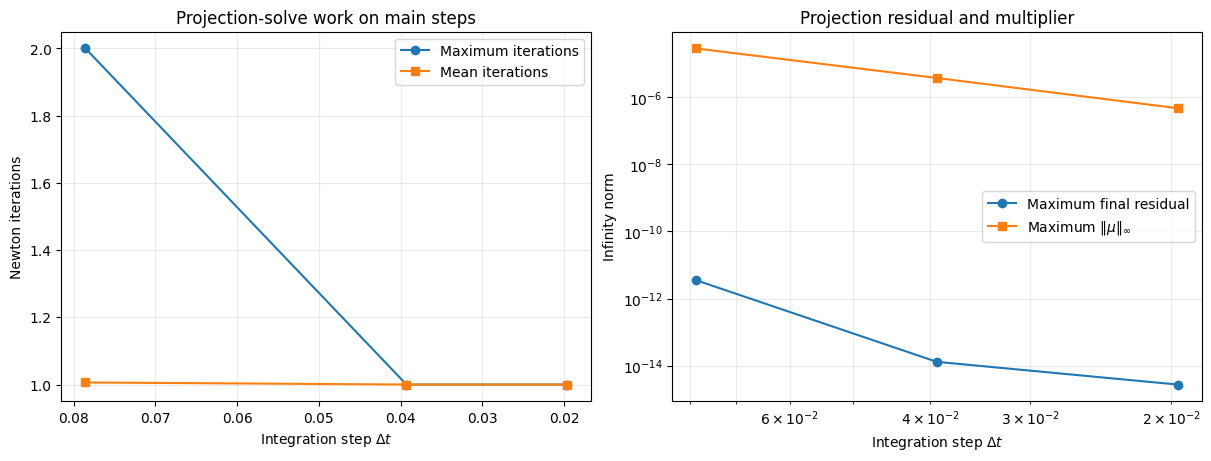

In [7]:
solver_figure, solver_axes = result.plot_solver_diagnostics()

## Comparative animation

The animation synchronizes the effective potential, transported ABBA contours, relative polygon-area error, and accumulated exact-tangent symplecticity defect. The same color identifies each step size in every panel.

In [8]:
display_animation(
    result.animate(
        frames=None,
        interval=120,
    )
)

## Interpretation

This experiment measures the implemented ideal-root tangent rather than a centered-difference approximation of the finite-iteration control flow. Local defects test the exact formula $\mathcal P-\mathcal Q\operatorname{solve}(\mathcal K,\mathcal L)$ at each converged stage set; accumulated defects test the ordered product of those matrices. Small nonzero values are therefore a numerical floor from Newton tolerance, interpolated Hessians, and floating-point accumulation. Polygonal area error remains a separate finite-boundary diagnostic and should not be identified with the matrix symplecticity defect.